In [145]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.ensemble import RandomForestClassifier



In [146]:
df= pd.read_csv('steel_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11822 entries, 0 to 11821
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              11822 non-null  int64  
 1   X_Maximum              11822 non-null  int64  
 2   Y_Minimum              11822 non-null  int64  
 3   Y_Maximum              11822 non-null  int64  
 4   Pixels_Areas           11822 non-null  int64  
 5   X_Perimeter            11822 non-null  int64  
 6   Y_Perimeter            11822 non-null  int64  
 7   Sum_of_Luminosity      11822 non-null  int64  
 8   Minimum_of_Luminosity  11822 non-null  int64  
 9   Maximum_of_Luminosity  11822 non-null  int64  
 10  Length_of_Conveyer     11822 non-null  int64  
 11  Steel_Plate_Thickness  11822 non-null  int64  
 12  Edges_Index            11822 non-null  float64
 13  Empty_Index            11822 non-null  float64
 14  Square_Index           11822 non-null  float64
 15  Ou

In [147]:
# Drop Dirtiness and Pastry
df = df[
    ~df['Defect_Type'].isin([
        'Dirtiness',
        'Pastry'
    ])
].copy()

print(df['Defect_Type'].value_counts())

Defect_Type
Bumps        4761
K_Scatch     3395
Z_Scratch    1150
Stains        567
Name: count, dtype: int64


In [148]:
steel_encoder = LabelEncoder()
defect_encoder = LabelEncoder()

df['Steel_Type'] = steel_encoder.fit_transform(df['Steel_Type'])
df['Defect_Type'] = defect_encoder.fit_transform(df['Defect_Type'])
print(df['Steel_Type'].value_counts().sort_index())
print(df['Defect_Type'].value_counts().sort_index())

print(dict(enumerate(steel_encoder.classes_)))
print(dict(enumerate(defect_encoder.classes_)))

Steel_Type
0    3868
1    6005
Name: count, dtype: int64
Defect_Type
0    4761
1    3395
2     567
3    1150
Name: count, dtype: int64
{0: 'A300', 1: 'A400'}
{0: 'Bumps', 1: 'K_Scatch', 2: 'Stains', 3: 'Z_Scratch'}


In [150]:
practical_features = [
    'Pixels_Areas',
    'X_Perimeter',
    'Y_Perimeter',
    'Steel_Plate_Thickness',
    'Length_of_Conveyer',
    'Maximum_of_Luminosity',
    'Minimum_of_Luminosity',
    'Sum_of_Luminosity',
    'X_Maximum',
    'Y_Maximum',
    'Steel_Type'
]

X = df[practical_features]
y = df['Defect_Type']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


In [152]:

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)


# Training
xgb_model.fit(X_train, y_train)

# Prediction
y_pred = xgb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9220121539500338

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1428
           1       0.98      0.95      0.96      1019
           2       0.96      0.89      0.92       170
           3       0.83      0.76      0.79       345

    accuracy                           0.92      2962
   macro avg       0.92      0.89      0.90      2962
weighted avg       0.92      0.92      0.92      2962



In [153]:
train_pred = xgb_model.predict(X_train)
test_pred = xgb_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print("Gap            :", train_acc - test_acc)

Train Accuracy : 0.9740992620460136
Test Accuracy  : 0.9220121539500338
Gap            : 0.05208710809597983


In [137]:
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Fold Scores :", scores)
print("Mean CV Accuracy :", np.mean(scores))
print("Std Dev :", np.std(scores))

Fold Scores : [0.91341772 0.92506329 0.91898734 0.9154002  0.91438703]
Mean CV Accuracy : 0.9174511176945866
Std Dev : 0.004246606434126412


In [138]:
train_pred = xgb_model.predict(X_train)

print(
    "Train Accuracy:",
    accuracy_score(y_train, train_pred)
)

Train Accuracy: 0.974533352626248


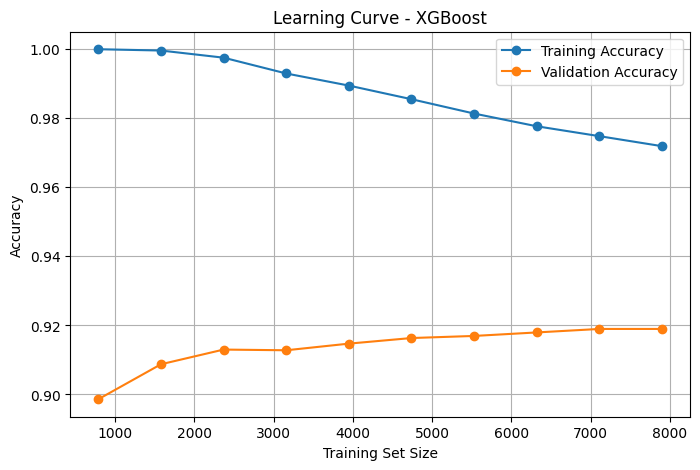

In [139]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=xgb_model,
    X=X,
    y=y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [154]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))





Accuracy: 0.9186360567184335


In [155]:
deployment_info = {
    "feature_order": list(X.columns),
    "defect_mapping": {
        i: cls
        for i, cls in enumerate(defect_encoder.classes_)
    },
    "steel_mapping": {
        i: cls
        for i, cls in enumerate(steel_encoder.classes_)
    },
    "model_params": xgb_model.get_params()
}

print(deployment_info)

{'feature_order': ['Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Steel_Plate_Thickness', 'Length_of_Conveyer', 'Maximum_of_Luminosity', 'Minimum_of_Luminosity', 'Sum_of_Luminosity', 'X_Maximum', 'Y_Maximum', 'Steel_Type'], 'defect_mapping': {0: 'Bumps', 1: 'K_Scatch', 2: 'Stains', 3: 'Z_Scratch'}, 'steel_mapping': {0: 'A300', 1: 'A400'}, 'model_params': {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi

In [156]:
feature_order = [
    'Pixels_Areas',
    'X_Perimeter',
    'Y_Perimeter',
    'Steel_Plate_Thickness',
    'Length_of_Conveyer',
    'Maximum_of_Luminosity',
    'Minimum_of_Luminosity',
    'Sum_of_Luminosity',
    'X_Maximum',
    'Y_Maximum',
    'Steel_Type'
]
feature_limits = {
    col: {
        "min": float(df[col].min()),
        "max": float(df[col].max())
    }
    for col in feature_order
}

print(feature_limits)

{'Pixels_Areas': {'min': 6.0, 'max': 152655.0}, 'X_Perimeter': {'min': 2.0, 'max': 7553.0}, 'Y_Perimeter': {'min': 2.0, 'max': 903.0}, 'Steel_Plate_Thickness': {'min': 40.0, 'max': 300.0}, 'Length_of_Conveyer': {'min': 1227.0, 'max': 1715.0}, 'Maximum_of_Luminosity': {'min': 71.0, 'max': 252.0}, 'Minimum_of_Luminosity': {'min': 0.0, 'max': 196.0}, 'Sum_of_Luminosity': {'min': 250.0, 'max': 11591414.0}, 'X_Maximum': {'min': 4.0, 'max': 1713.0}, 'Y_Maximum': {'min': 6724.0, 'max': 12987692.0}, 'Steel_Type': {'min': 0.0, 'max': 1.0}}


In [157]:
import joblib

artifacts = {
    "model": xgb_model,
    "steel_encoder": steel_encoder,
    "defect_encoder": defect_encoder,
    "feature_order": list(X.columns)
}

joblib.dump(
    artifacts,
    "steel_defect_artifacts.pkl"
)

print("Artifacts saved successfully!")

Artifacts saved successfully!
